In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../Dataset/ConsumptionIndustry.csv', sep=';')

df['HourDK'] = pd.to_datetime(df['HourDK'])
df['ConsumptionkWh'] = df['ConsumptionkWh'].str.replace(",", ".").astype(float)
df.index = df['HourDK']
df.drop(columns=['HourUTC', 'HourDK', 'MunicipalityNo', 'Branche'], inplace=True)

df2 = pd.read_csv('../Dataset/ELSpotPrices.csv', sep=';')
df2['HourDK'] = pd.to_datetime(df2['HourDK'])
df2['SpotPriceDKK'] = df2['SpotPriceDKK'].str.replace(",", ".").astype(float)
df2.index = df2['HourDK']
df2.drop(columns=['HourUTC', 'HourDK', 'PriceArea', 'SpotPriceEUR'], inplace=True)

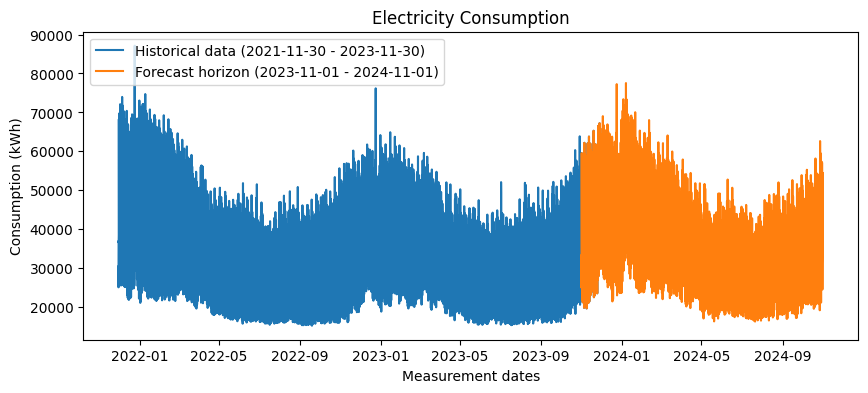

In [9]:
train_start = "2021-11-30"
train_end = "2023-11-30"
test_start = "2023-11-01"
test_end = "2024-11-01"

data_train = df[(df.index >= train_start) & (df.index <= train_end)]
data_test = df[(df.index >= test_start) & (df.index <= test_end)]

plt.figure(figsize=(10, 4))
plt.plot(data_train.index, data_train['ConsumptionkWh'], label=f'Historical data ({train_start} - {train_end})')
plt.plot(data_test.index, data_test['ConsumptionkWh'], label=f'Forecast horizon ({test_start} - {test_end})')
plt.title('Electricity Consumption')
plt.xlabel('Measurement dates')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.show()


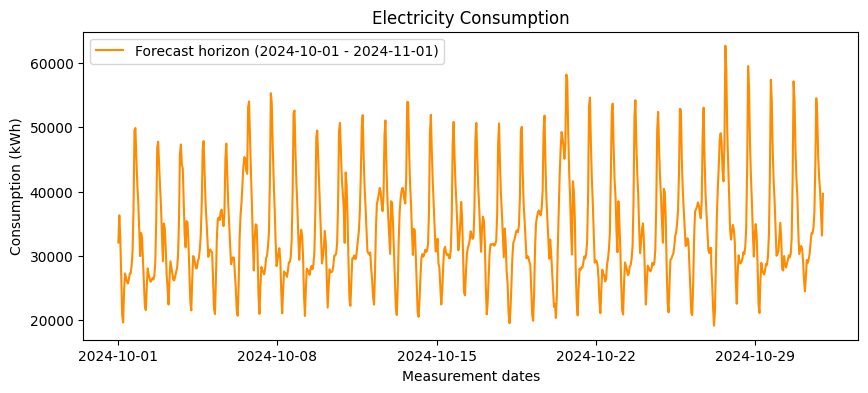

In [10]:
date_start = "2024-10-01"
date_end = "2024-11-01"
df_figure = df[(df.index >= date_start) & (df.index <= date_end)]

plt.figure(figsize=(10, 4))
plt.plot(df_figure.index, df_figure['ConsumptionkWh'], label=f'Forecast horizon ({date_start} - {date_end})', color='darkorange')
plt.title('Electricity Consumption')
plt.xlabel('Measurement dates')
plt.ylabel('Consumption (kWh)')
plt.legend()

plt.xticks(pd.date_range(start=date_start, end=date_end, freq='7D'), rotation=0)
plt.show()

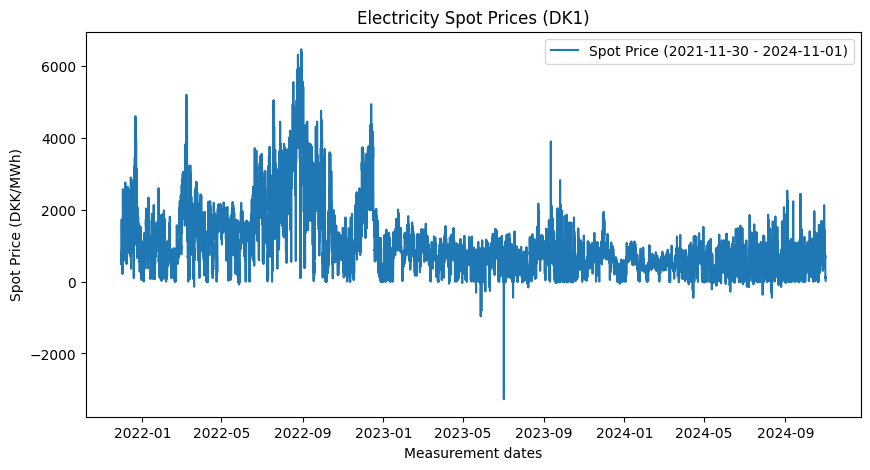

In [14]:
train_start = "2021-11-30"
train_end = "2024-11-01"

data_train = df2[(df2.index >= train_start) & (df2.index <= train_end)]
data_test = df2[(df2.index >= test_start) & (df2.index <= test_end)]

plt.figure(figsize=(10, 5))
plt.plot(data_train.index, data_train['SpotPriceDKK'], label=f'Spot Price ({train_start} - {train_end})')
plt.title('Electricity Spot Prices (DK1)')
plt.xlabel('Measurement dates')
plt.ylabel('Spot Price (DKK/MWh)')
plt.legend()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


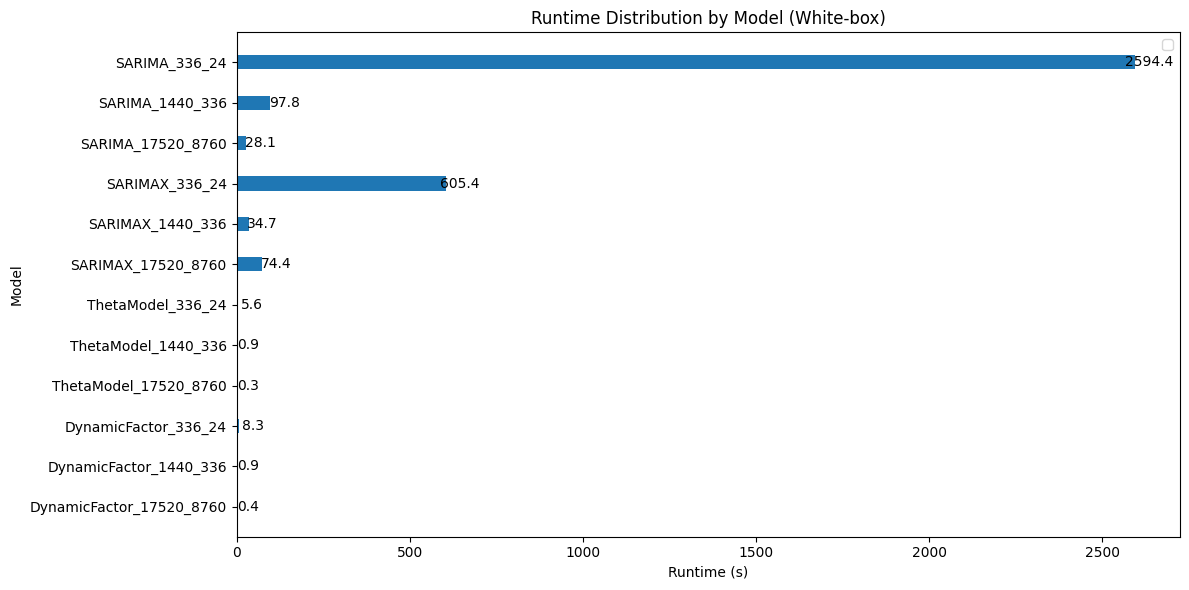

In [45]:
a = pd.read_csv('../Results/whitebox_run_stats.csv', sep=',')

# Group by 'model' and sum the 'runtime' values
a_grouped = a.groupby('model')['runtime'].sum().reset_index()

# Define the custom order for the models
custom_order = [
    'SARIMA_336_24', 'SARIMA_1440_336', 'SARIMA_17520_8760',
    'SARIMAX_336_24', 'SARIMAX_1440_336', 'SARIMAX_17520_8760',
    'ThetaModel_336_24', 'ThetaModel_1440_336', 'ThetaModel_17520_8760',
    'DynamicFactor_336_24', 'DynamicFactor_1440_336', 'DynamicFactor_17520_8760',
]
custom_order.reverse()

# Filter the DataFrame to include only models in the custom order
a_grouped = a_grouped[a_grouped['model'].isin(custom_order)]

# Convert the 'model' column to a categorical type with the custom order
a_grouped['model'] = pd.Categorical(a_grouped['model'], categories=custom_order, ordered=True)

# Sort the DataFrame based on the custom order
a_grouped = a_grouped.sort_values('model')

# Set the index to 'model' for plotting
a_grouped.set_index('model', inplace=True)

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Define the bar width and positions
bar_width = 0.35
index = np.arange(len(a_grouped))

# Create horizontal bars for whitebox runtimes
bars = ax.barh(index, a_grouped['runtime'], bar_width)

# Add labels, title, and legend
ax.set_xlabel('Runtime (s)')
ax.set_ylabel('Model')
ax.set_title('Runtime Distribution by Model (White-box)')
ax.set_yticks(index)
ax.set_yticklabels(a_grouped.index)
ax.legend()

# Add values inside the bars
for bar in bars:
    width = bar.get_width()
    if width < 5:  # Adjust this threshold as needed
        ax.text(width + 1, bar.get_y() + bar.get_height() / 2, f'{width:.1f}', ha='left', va='center', color='black')
    else:
        ax.text(width + 40, bar.get_y() + bar.get_height() / 2, f'{width:.1f}', ha='center', va='center', color='black')

# Display the bar chart
plt.tight_layout()
plt.show()

In [ ]:
a = pd.read_csv('../Results/blackbox_run_stats.csv', sep=',')

# Group by 'model' and sum the 'runtime' values
a_grouped = a.groupby('model')['runtime'].sum().reset_index()

# Define the custom order for the models
custom_order = [
    'SARIMA_336_24', 'SARIMA_1440_336', 'SARIMA_17520_8760',
    'SARIMAX_336_24', 'SARIMAX_1440_336', 'SARIMAX_17520_8760',
    'ThetaModel_336_24', 'ThetaModel_1440_336', 'ThetaModel_17520_8760',
    'DynamicFactor_336_24', 'DynamicFactor_1440_336', 'DynamicFactor_17520_8760',
]
custom_order.reverse()

# Filter the DataFrame to include only models in the custom order
a_grouped = a_grouped[a_grouped['model'].isin(custom_order)]

# Convert the 'model' column to a categorical type with the custom order
a_grouped['model'] = pd.Categorical(a_grouped['model'], categories=custom_order, ordered=True)

# Sort the DataFrame based on the custom order
a_grouped = a_grouped.sort_values('model')

# Set the index to 'model' for plotting
a_grouped.set_index('model', inplace=True)

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Define the bar width and positions
bar_width = 0.35
index = np.arange(len(a_grouped))

# Create horizontal bars for whitebox runtimes
bars = ax.barh(index, a_grouped['runtime'], bar_width)

# Add labels, title, and legend
ax.set_xlabel('Runtime (s)')
ax.set_ylabel('Model')
ax.set_title('Runtime Distribution by Model (White-box)')
ax.set_yticks(index)
ax.set_yticklabels(a_grouped.index)
ax.legend()

# Add values inside the bars
for bar in bars:
    width = bar.get_width()
    if width < 5:  # Adjust this threshold as needed
        ax.text(width + 1, bar.get_y() + bar.get_height() / 2, f'{width:.1f}', ha='left', va='center', color='black')
    else:
        ax.text(width + 40, bar.get_y() + bar.get_height() / 2, f'{width:.1f}', ha='center', va='center', color='black')

# Display the bar chart
plt.tight_layout()
plt.show()